# 최종 모델

`variable_refinement_model_selection`까지의 과정을 반영해 원핫 인코딩, 파생변수 생성, CatBoost 학습, SHAP 분석까지 한 번에 실행하는 최종 CatBoost 모델입니다. 이 노트북만으로 처음부터 끝까지 실행할 수 있습니다.

**최종 성능**: Accuracy 0.768 / Precision 0.811 / Recall 0.813 / F1 0.812 / AUC 0.820

# 7. 최종 모델 (단독 실행)
<small>지금까지의 과정을 반영해 원핫 인코딩, 파생변수 생성, CatBoost 학습, SHAP 분석까지 한 번에 실행하는 최종 버전입니다.</small>

In [1]:
# 최종 모델 단독 실행용 데이터 불러오기 (위 단계와 독립적으로 원본에서 다시 시작)
from pathlib import Path
import pandas as pd

DATA_FILE = Path("../data/data(drop_duplicated).csv")

df_final = pd.read_csv(DATA_FILE)
drop_df = df_final.copy()

In [2]:
drop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     2043 non-null   object 
 1   songName                2043 non-null   object 
 2   artists                 2043 non-null   object 
 3   video_id                2043 non-null   object 
 4   api_view_count          2043 non-null   float64
 5   api_like_count          2043 non-null   float64
 6   api_comment_count       2043 non-null   float64
 7   api_published_at        2043 non-null   object 
 8   api_duration            2043 non-null   object 
 9   api_channel_title       2043 non-null   object 
 10  valence_raw             2043 non-null   float64
 11  arousal_raw             2043 non-null   float64
 12  valence_normalized      2043 non-null   float64
 13  arousal_normalized      2043 non-null   float64
 14  energy                  2043 non-null   

[ 파생변수 생성 완료 ]
데이터 shape    : (2043, 22)
Hit  (≥100만뷰) : 1259개 (61.63%)
Non-Hit         : 784개 (38.37%)
피처 수         : 22

[CatBoost 결과 (th=0.5, class_weights={0:1.4, 1:1.0})]
Accuracy : 0.7680
Precision: 0.8113
Recall   : 0.8125
F1       : 0.8119
AUC      : 0.8204

Confusion Matrix
TN=546, FP=238, FN=236, TP=1023


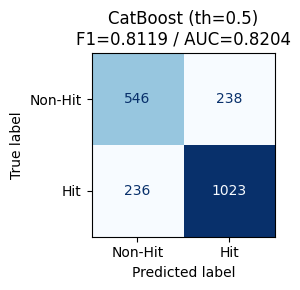

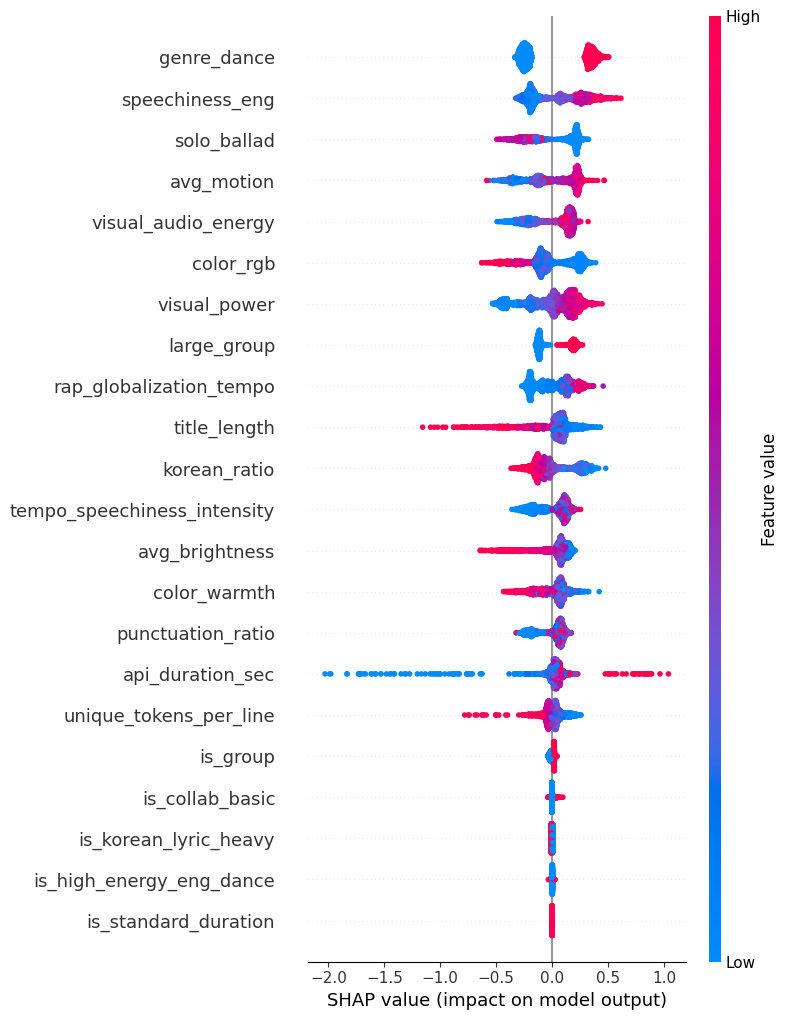

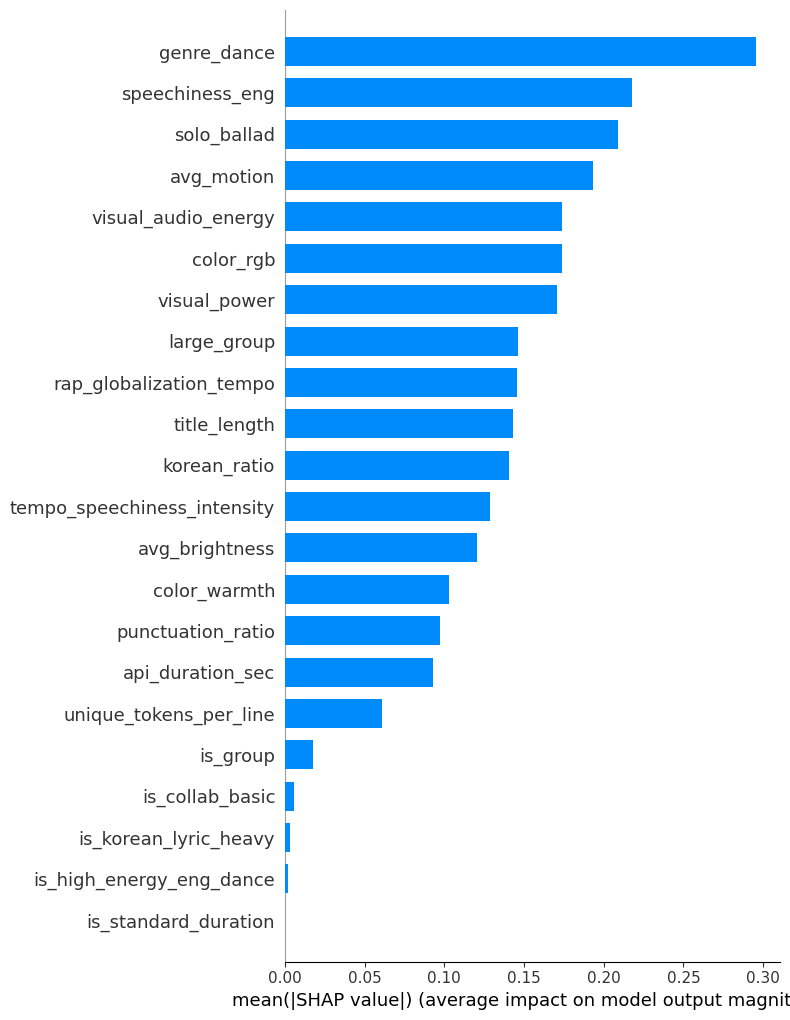


[SHAP 특징 중요도]
                    feature  mean_shap
                genre_dance   0.295740
            speechiness_eng   0.217741
                solo_ballad   0.208920
                 avg_motion   0.193467
        visual_audio_energy   0.173971
                  color_rgb   0.173528
               visual_power   0.170620
                large_group   0.146072
    rap_globalization_tempo   0.145778
               title_length   0.143226
               korean_ratio   0.140519
tempo_speechiness_intensity   0.128808
             avg_brightness   0.120671
               color_warmth   0.103093
          punctuation_ratio   0.097529
           api_duration_sec   0.093040
     unique_tokens_per_line   0.060969
                   is_group   0.017336
            is_collab_basic   0.005391
      is_korean_lyric_heavy   0.003213
   is_high_energy_eng_dance   0.001880
       is_standard_duration   0.000000

>> Saved: catboost_final_result.csv
>> Saved: shap_importance_final.csv

[FP 곡 목록: 총 23

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay)
from catboost import CatBoostClassifier
import shap

# ── 원핫 인코딩 ──
if 'genie_genre' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['genie_genre'], prefix='genre', drop_first=True)
    drop_df = drop_df.rename(columns={
        'genre_댄스':      'genre_dance',
        'genre_발라드':    'genre_ballad',
        'genre_랩/힙합':   'genre_rap_hiphop',
        'genre_인디':      'genre_indie',
        'genre_락':        'genre_rock',
        'genre_일렉트로니카': 'genre_electronic',
        'genre_팝':        'genre_pop',
    })
if 'gender' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['gender'], prefix='gender')

# ── 파생변수 생성 ──
drop_df['rap_globalization_tempo']     = drop_df['speechiness'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['speechiness_eng']             = drop_df['token_count'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['visual_power']                = drop_df['avg_motion'] * drop_df['energy']
drop_df['color_warmth']                = drop_df['avg_r_value'] - drop_df['avg_b_value']
drop_df['visual_audio_energy']         = drop_df['avg_motion'] * drop_df['loudness'].abs()
# solo_ballad: 실험 과정에서 감성 항목을 바꿨고(3단계 1 - valence → 5단계 |sentiment_compound|), 최종 모델은 부정 감성(sentiment_negative) 기준입니다.
drop_df['solo_ballad']                 = (1 - drop_df['is_group']) * (1 / (drop_df['tempo'] + 1)) * drop_df['sentiment_negative']
drop_df['large_group']                 = ((drop_df['is_group'] == 1) & (drop_df['member_count'] >= 5)).astype(int)
drop_df['is_collab_basic']             = drop_df['songName'].str.contains(
    r'feat\.|feat |Feat\.|Feat |FEAT\.|FEAT |Prod\.|prod\.', case=False, regex=True
).astype(int)
drop_df['is_standard_duration']        = ((drop_df['api_duration_sec'] >= 30) & (drop_df['api_duration_sec'] <= 600)).astype(int)
drop_df['title_length']                = drop_df['songName'].str.len()
drop_df['color_rgb']                   = drop_df['avg_r_value'] * drop_df['avg_g_value'] * drop_df['avg_b_value']
drop_df['is_korean_lyric_heavy']       = ((drop_df['genre_dance'] == 0) & (drop_df['korean_ratio'] >= 0.7)).astype(int)
drop_df['is_high_energy_eng_dance']    = ((drop_df['genre_dance'] == 1) & (drop_df['english_ratio'] >= 0.5) & (drop_df['energy'] >= 0.25)).astype(int)
drop_df['tempo_speechiness_intensity'] = drop_df['tempo'] * drop_df['speechiness']

print("[ 파생변수 생성 완료 ]")

# ── 피처 정의 ──
FEATURES = [
    'rap_globalization_tempo',
    'avg_motion',
    'visual_audio_energy', 'visual_power', 'color_warmth', 'avg_brightness',
    'speechiness_eng', 'korean_ratio', 'unique_tokens_per_line', 'punctuation_ratio',
    'api_duration_sec', 'is_standard_duration',
    'is_group', 'large_group', 'genre_dance', 'solo_ballad',
    'is_collab_basic', 'title_length', 'color_rgb',
    'is_korean_lyric_heavy', 'is_high_energy_eng_dance',
    'tempo_speechiness_intensity',
]
FEATURES = [f for f in FEATURES if f in drop_df.columns]

X = drop_df[FEATURES].copy()
y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print(f"데이터 shape    : {X.shape}")
print(f"Hit  (≥100만뷰) : {int((y==1).sum())}개 ({round(y.mean()*100, 2)}%)")
print(f"Non-Hit         : {int((y==0).sum())}개 ({round((1-y).mean()*100, 2)}%)")
print(f"피처 수         : {len(FEATURES)}")
print("=" * 60)

# ── K-Fold 루프 ──
y_prob = np.zeros(len(y))
for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train         = y.iloc[train_idx]

    model = CatBoostClassifier(
        iterations=          788,
        learning_rate=       0.011885273757139162,
        depth=               4,
        l2_leaf_reg=         3.4613612153138447,
        bagging_temperature= 0.5439643881117773,
        random_strength=     0.4456162098021036,
        border_count=        81,
        class_weights=       {0: 1.4, 1: 1.0},
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=0,
    )
    model.fit(X_train, y_train)
    y_prob[val_idx] = model.predict_proba(X_val)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec  = recall_score(y, y_pred)
f1   = f1_score(y, y_pred)
auc  = roc_auc_score(y, y_prob)

print("\n[CatBoost 결과 (th=0.5, class_weights={0:1.4, 1:1.0})]")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"\nConfusion Matrix")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# ── Confusion Matrix 시각화 ──
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CatBoost (th=0.5)\nF1={f1:.4f} / AUC={auc:.4f}")
plt.tight_layout()
plt.savefig('catboost_final_cm.png', dpi=120)
plt.show()

# ── SHAP 분석 ──
best_model = CatBoostClassifier(
    iterations=          788,
    learning_rate=       0.011885273757139162,
    depth=               4,
    l2_leaf_reg=         3.4613612153138447,
    bagging_temperature= 0.5439643881117773,
    random_strength=     0.4456162098021036,
    border_count=        81,
    class_weights=       {0: 1.4, 1: 1.0},
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
)
best_model.fit(X, y)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X, feature_names=FEATURES, max_display=len(FEATURES), show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X, feature_names=FEATURES, plot_type='bar', max_display=len(FEATURES), show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n[SHAP 특징 중요도]")
print(shap_importance.to_string(index=False))

pd.DataFrame([{
    '모델': 'CatBoost_Optuna200_final',
    'Accuracy':  round(acc,  4),
    'Precision': round(prec, 4),
    'Recall':    round(rec,  4),
    'F1':        round(f1,   4),
    'AUC':       round(auc,  4),
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
}]).to_csv('catboost_final_result.csv', index=False)
print("\n>> Saved: catboost_final_result.csv")

shap_importance.to_csv('shap_importance_final.csv', index=False)
print(">> Saved: shap_importance_final.csv")

result_df = drop_df[['songName', 'artists', 'api_view_count', 'url']].copy()
result_df['y_true'] = y.values
result_df['y_pred'] = y_pred
result_df['y_prob'] = y_prob

fp_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)].sort_values('y_prob', ascending=False)
fn_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)].sort_values('y_prob', ascending=True)

print(f"\n[FP 곡 목록: 총 {len(fp_df)}개]")
print(fp_df.to_string(index=False))
print(f"\n[FN 곡 목록: 총 {len(fn_df)}개]")
print(fn_df.to_string(index=False))

fp_df.to_csv('fp_songs.csv', index=False)
fn_df.to_csv('fn_songs.csv', index=False)
print("\n>> Saved: fp_songs.csv, fn_songs.csv")

## 최종 결과 해석

<small>SHAP 중요도 상위 변수: `genre_dance`(0.296) > `speechiness_eng`(0.218) > `solo_ballad`(0.209) > `avg_motion`(0.193) > `visual_audio_energy`(0.174) > `color_rgb`(0.174) > `visual_power`(0.171) > `large_group`(0.146) > `rap_globalization_tempo`(0.146) > `title_length`(0.143) > `korean_ratio`(0.141)</small>

> **확인 결과**: "SHAP 분석으로 시청각 임팩트·글로벌 가사 전략이 핵심 성공 요인으로 확인"이라는 해석은 SHAP 결과와 대체로 일치합니다. `avg_motion`·`visual_audio_energy`·`visual_power`·`color_rgb`(시청각 임팩트)와 `speechiness_eng`·`rap_globalization_tempo`·`korean_ratio`(글로벌 가사 전략) 관련 변수들이 상위 11개 중 7개를 차지합니다. 다만 SHAP 중요도 1위는 이 두 축이 아니라 **장르 변수(`genre_dance`, 댄스 장르 여부)**입니다 — 시청각·가사 전략이 핵심 요인이라는 해석은 맞지만, 가장 강력한 단일 변수는 '댄스 장르 여부'라는 점은 참고하시면 좋을 것 같습니다.